In [2]:
# Importing Libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [3]:
# Initializing Device
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
# Loading Dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(224, padding=16),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
train_dataset = datasets.CIFAR100(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = datasets.CIFAR100(
    root="./data",
    train=False,
    download=True,
    transform=test_transform
)

class_names = train_dataset.classes

print("Train size:", len(train_dataset))
print("Test size:", len(test_dataset))
print("Classes:", len(class_names))

100%|██████████| 169M/169M [00:13<00:00, 12.5MB/s]


Train size: 50000
Test size: 10000
Classes: 100


In [5]:
# Dataloader
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [6]:
# Loading Resnet18
resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = resnet.fc.in_features
resnet.fc = nn.Linear(num_features, 100)
resnet = resnet.to(device)
print(resnet.fc)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


Linear(in_features=512, out_features=100, bias=True)


In [7]:
# Loss, Optimizer & Scheduler
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    resnet.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.StepLR(
    optimizer,
    step_size=5,
    gamma=0.1
)

In [8]:
# Training Function
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [9]:
# Evaluation Function
def evaluate_model(model, loader, criterion):
    model.eval()
    running_loss = 0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []
    with torch.no_grad():
        for images, labels in tqdm(loader):
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
            all_predictions.extend(predictions.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy, all_predictions, all_labels

In [10]:
# Training Resnet18
EPOCHS = 5
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
best_accuracy = 0

for epoch in range(EPOCHS):

    print("\n" + "=" * 50)
    print(f"Epoch {epoch + 1}/{EPOCHS}")
    print("=" * 50)

    train_loss, train_acc = train_one_epoch(
        resnet,
        train_loader,
        criterion,
        optimizer
    )

    test_loss, test_acc, _, _ = evaluate_model(
        resnet,
        test_loader,
        criterion
    )

    scheduler.step()
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accuracies.append(train_acc * 100)
    test_accuracies.append(test_acc * 100)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc * 100:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")

    if test_acc > best_accuracy:
        best_accuracy = test_acc
        torch.save(
            resnet.state_dict(),
            "best_resnet18_cifar100.pth"
        )

        print("Best model saved!")


Epoch 1/5


100%|██████████| 157/157 [00:18<00:00,  8.61it/s]


Train Loss: 1.7052
Train Accuracy: 59.35%
Test Loss: 0.9541
Test Accuracy: 73.04%
Best model saved!

Epoch 2/5


100%|██████████| 157/157 [00:18<00:00,  8.67it/s]


Train Loss: 0.7982
Train Accuracy: 77.73%
Test Loss: 0.7730
Test Accuracy: 77.67%
Best model saved!

Epoch 3/5


...

Train Loss: 0.5764
Train Accuracy: 83.60%
Test Loss: 0.7173
Test Accuracy: 78.83%
Best model saved!

Epoch 4/5


100%|██████████| 157/157 [00:18<00:00,  8.69it/s]


Train Loss: 0.4434
Train Accuracy: 87.14%
Test Loss: 0.6919
Test Accuracy: 79.70%
Best model saved!

Epoch 5/5


100%|██████████| 157/157 [00:18<00:00,  8.61it/s]

Train Loss: 0.3396
Train Accuracy: 90.11%
Test Loss: 0.7237
Test Accuracy: 79.43%


In [11]:
# Final Evaluation
resnet.load_state_dict(
    torch.load("best_resnet18_cifar100.pth")
)

final_loss, final_acc, resnet_predictions, resnet_labels = evaluate_model(
    resnet,
    test_loader,
    criterion
)

print("=" * 50)
print("FINAL RESNET18 BASELINE RESULT")
print("=" * 50)
print(f"Final Test Accuracy: {final_acc * 100:.2f}%")

100%|██████████| 157/157 [00:18<00:00,  8.51it/s]

FINAL RESNET18 BASELINE RESULT
Final Test Accuracy: 79.70%


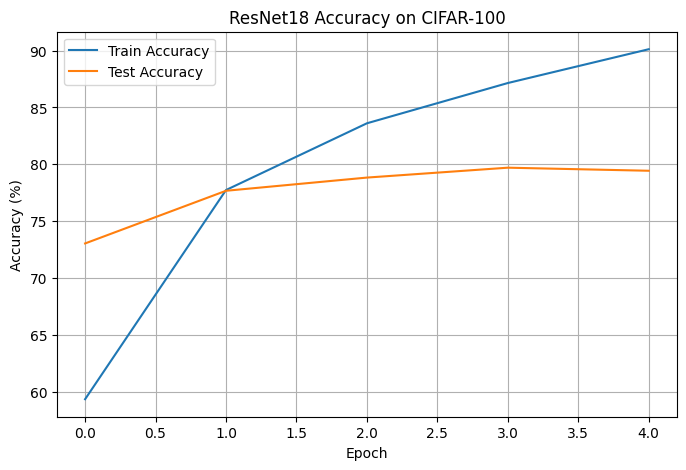

In [12]:
# Training Curve
plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(test_accuracies, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet18 Accuracy on CIFAR-100")
plt.legend()
plt.grid(True)
plt.show()

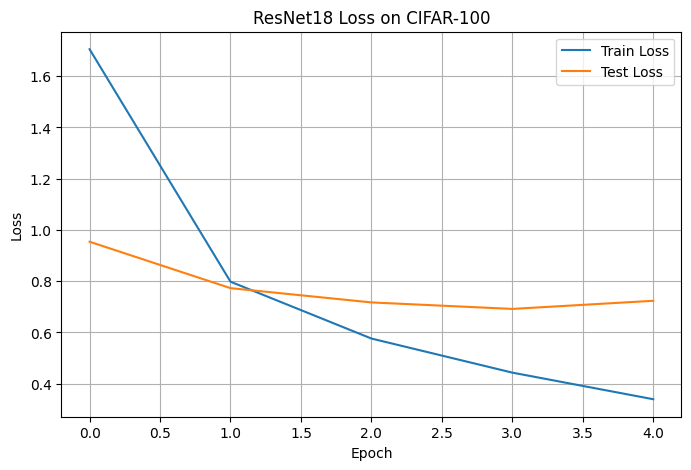

In [13]:
# Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet18 Loss on CIFAR-100")
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# Result
resnet18_accuracy = final_acc * 100
print(f"ResNet18 Baseline Accuracy: {resnet18_accuracy:.2f}%")

ResNet18 Baseline Accuracy: 79.70%
